<a href="https://colab.research.google.com/github/RR77ui/Business-Intelligence/blob/main/Aprendizaje%20Supervisado/Caso_Compra_Venta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Caso de negocio**
Una empresa de compra y venta de vehículos usados necesita optimizar su proceso de valoración de autos y estimacion de precios para lo cual cuenta con un dataset de precios de autos usado, este dataset cuenta con las siguientes variables:
Make: El fabricante o la marca del vehículo (ej., Toyota, BMW, Ford).

Model: La variante o el nivel de acabado del vehículo, etiquetado como 'a', 'b', 'c', 'd' o 'e'. Estos pueden representar diferentes niveles de equipamiento, características o configuraciones del mismo modelo de automóvil.

Year: El año en que se fabricó o lanzó el automóvil.

Engine Size: La capacidad del motor en litros (L), lo que indica su desplazamiento total y el nivel general de rendimiento.

Mileage : La distancia total que ha recorrido el automóvil, generalmente medida en kilómetros o millas.

Fuel Type: El tipo de  que utiliza el vehículo, como Gasolina (Petrol), Diésel (Diesel), Híbrido (Hybrid) o Eléctrico (Electric).

Transmission: El tipo de sistema de caja de cambios utilizado en el vehículo, comúnmente Manual o Automática.

Price-target: El precio de venta del vehículo en usd. Esta es la variable objetivo, utilizada para la predicción en modelos de regresión con el fin de estimar el valor del automóvil basándose en otras características.

Variable objetivo a predecir: Precio

Tipo de modelo: Regresion debido a que es una variable continua


Preguntas guia:
¿Cuáles son las características clave que más influyen en el precio de un auto usado (por ejemplo, el kilometraje, el año de fabricación o la marca)?

¿Qué tan sensible es el precio a los cambios en las variables del modelo?



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
#drive.mount('/content/drive')

0. Carga de los datos

In [ ]:
path = '/content/Car_Price_Prediction.csv'
df = pd.read_csv(path)
display(df.shape)
display(df.info())
display(df.describe())
display(df.describe(include=object))
df.head()

(1000, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


None

,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


,Make,Model,Fuel Type,Transmission
count,1000,1000,1000,1000
unique,5,5,3,2
top,Ford,Model B,Diesel,Manual
freq,225,212,344,511


,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [ ]:
# Mirar valores faltantes en el dataset
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64


1. Exploracion de los datos

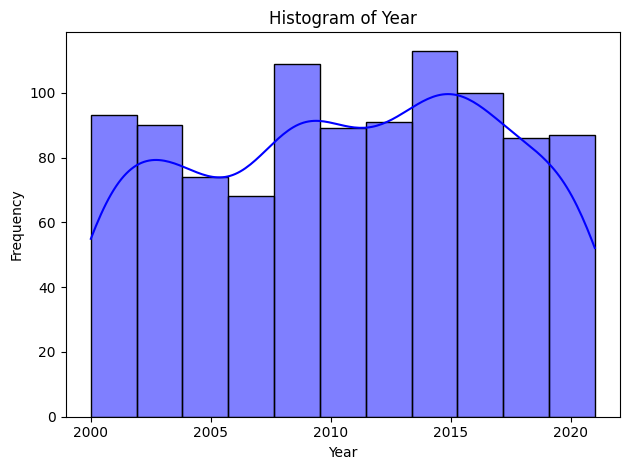

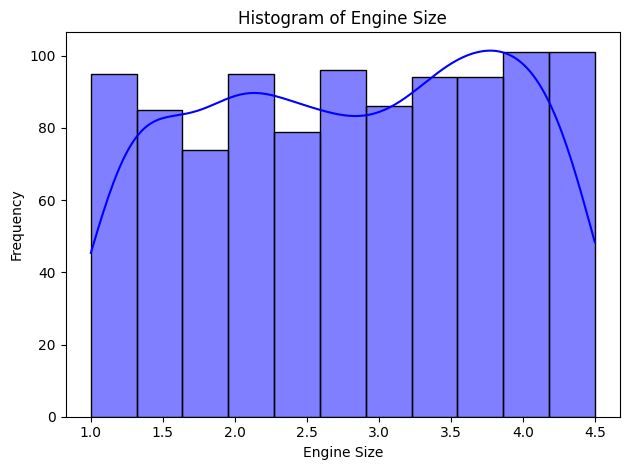

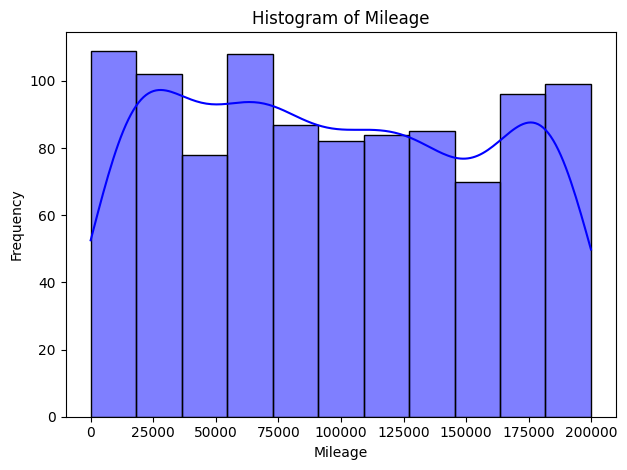

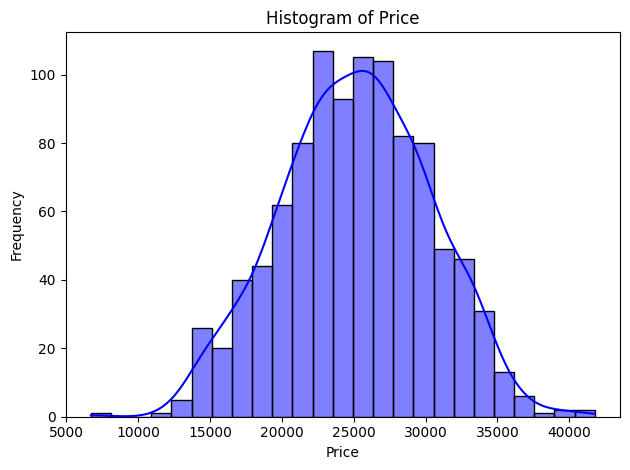

/tmp/ipython-input-3321305562.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=colc, data=df_cat, palette='viridis')


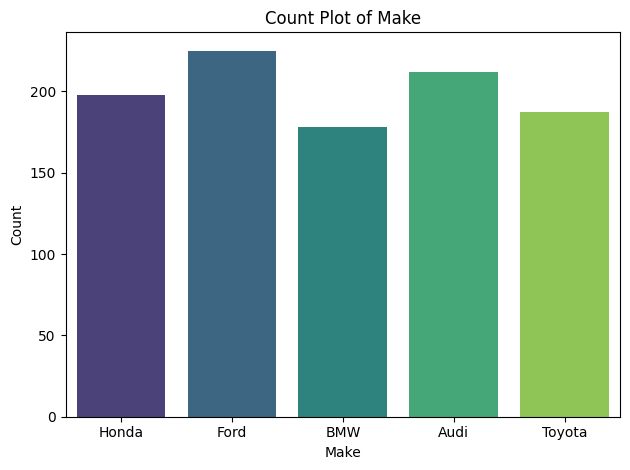

/tmp/ipython-input-3321305562.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=colc, data=df_cat, palette='viridis')


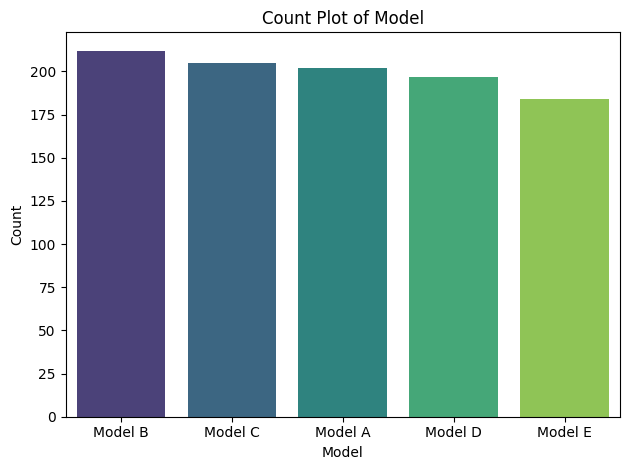

/tmp/ipython-input-3321305562.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=colc, data=df_cat, palette='viridis')


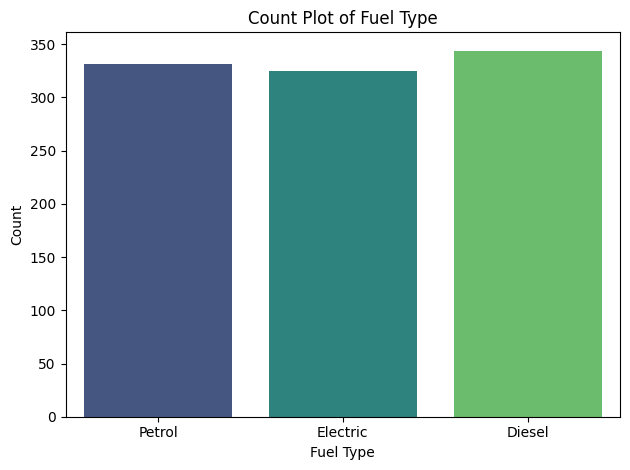

/tmp/ipython-input-3321305562.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=colc, data=df_cat, palette='viridis')


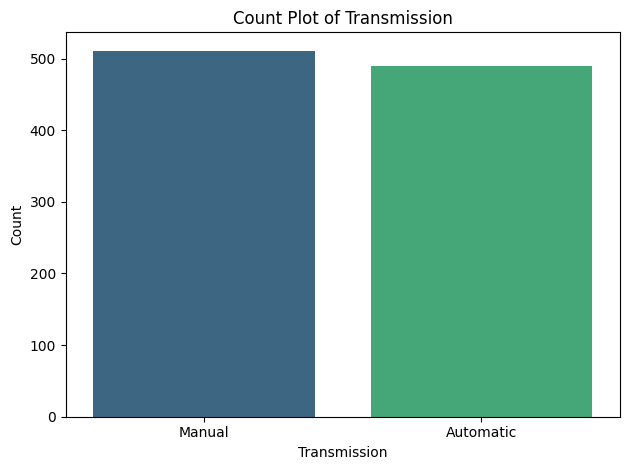

In [ ]:
df_num = df.select_dtypes(include=np.number)

for col in df_num.columns:
  plt.figure()
  sns.histplot(df_num[col], kde=True, color='blue')
  plt.title(f'Histogram of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()

df_cat = df.select_dtypes(include=object)
for colc in df_cat.columns:
  plt.figure()
  sns.countplot(x=colc, data=df_cat, palette='viridis')
  plt.title(f'Count Plot of {colc}')
  plt.xlabel(colc)
  plt.ylabel('Count')
  plt.tight_layout()
  plt.show()

In [ ]:
for col in df_num.columns:
    Q1 = df_num[col].quantile(0.25)
    Q3 = df_num[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_num[(df_num[col] < lower_bound) | (df_num[col] > upper_bound)]
    num_outliers = len(outliers)
    percentage_outliers = (num_outliers / len(df_num)) * 100

    print(f"Column '{col}':")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {num_outliers}")
    print(f"  Percentage of outliers: {percentage_outliers:.2f}%")
    if num_outliers > 0:
        print("  Outlier values (first 5 if more):\n", outliers[[col]].head())
    print("\n" + "-"*50 + "\n")

Column 'Year':
  Q1: 2005.00
  Q3: 2016.00
  IQR: 11.00
  Lower Bound: 1988.50
  Upper Bound: 2032.50
  Number of outliers: 0
  Percentage of outliers: 0.00%

--------------------------------------------------

Column 'Engine Size':
  Q1: 1.90
  Q3: 3.70
  IQR: 1.80
  Lower Bound: -0.80
  Upper Bound: 6.40
  Number of outliers: 0
  Percentage of outliers: 0.00%

--------------------------------------------------

Column 'Mileage':
  Q1: 44768.75
  Q3: 148977.75
  IQR: 104209.00
  Lower Bound: -111544.75
  Upper Bound: 305291.25
  Number of outliers: 0
  Percentage of outliers: 0.00%

--------------------------------------------------

Column 'Price':
  Q1: 21587.88
  Q3: 28806.37
  IQR: 7218.49
  Lower Bound: 10760.14
  Upper Bound: 39634.10
  Number of outliers: 3
  Percentage of outliers: 0.30%
  Outlier values (first 5 if more):
             Price
133  41780.504635
295  40538.382064
981   6704.953524

--------------------------------------------------



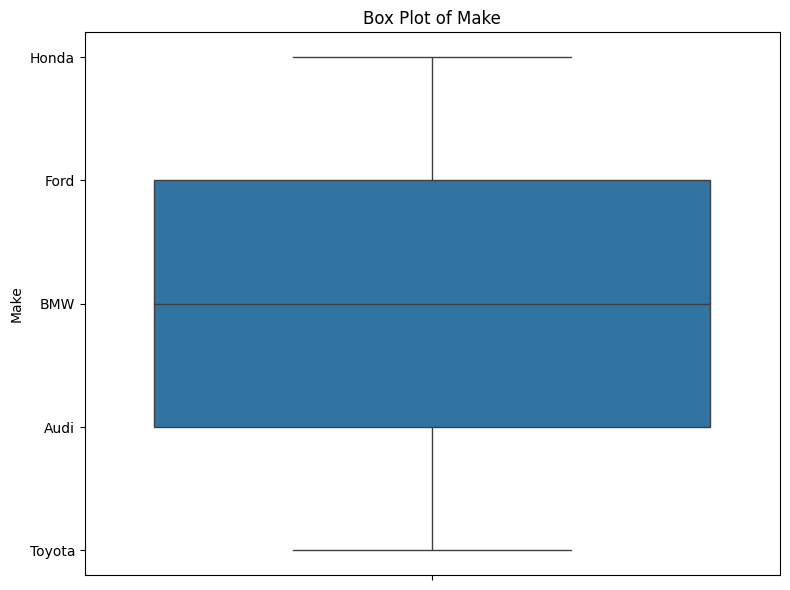

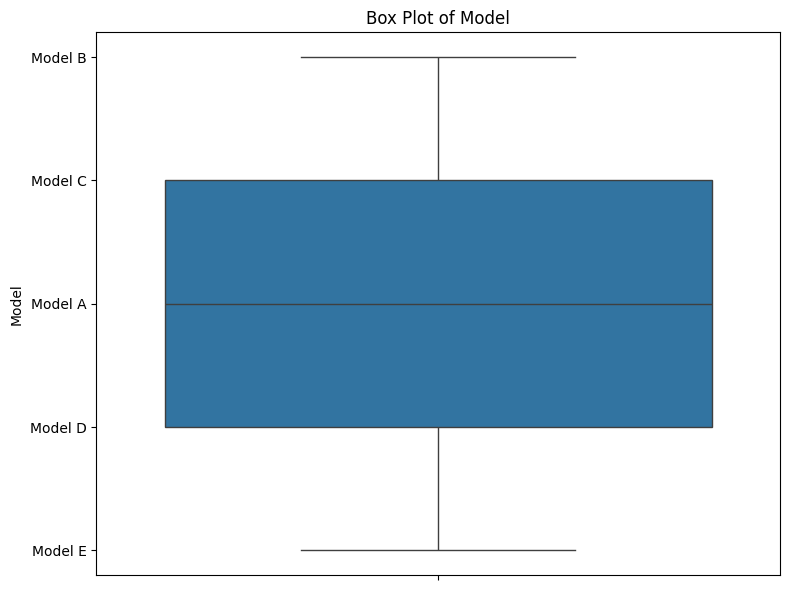

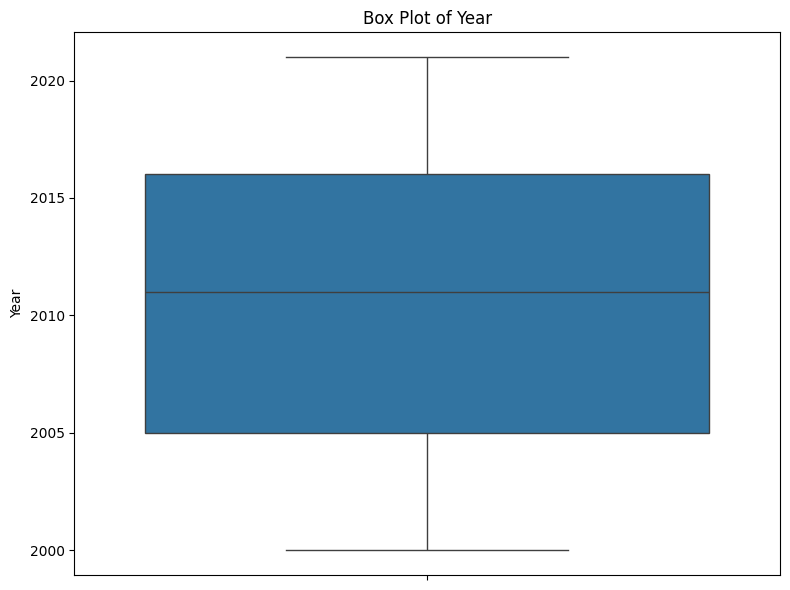

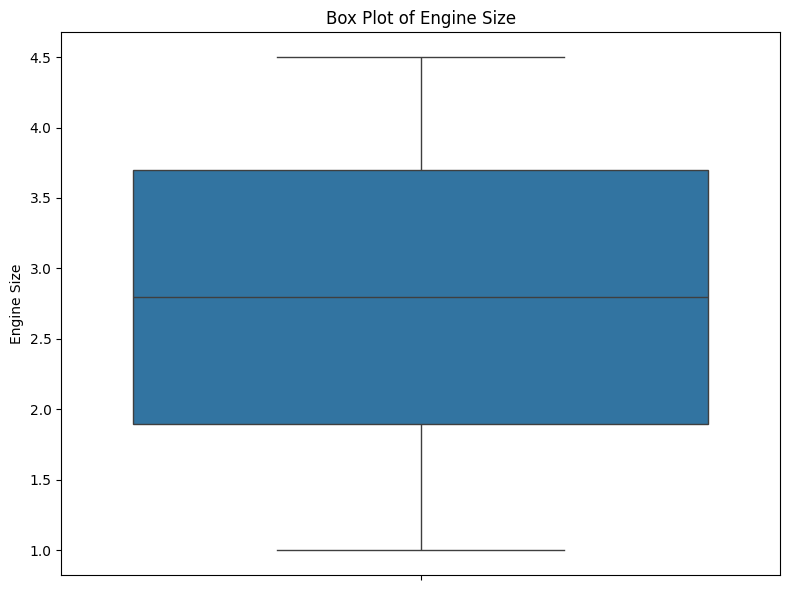

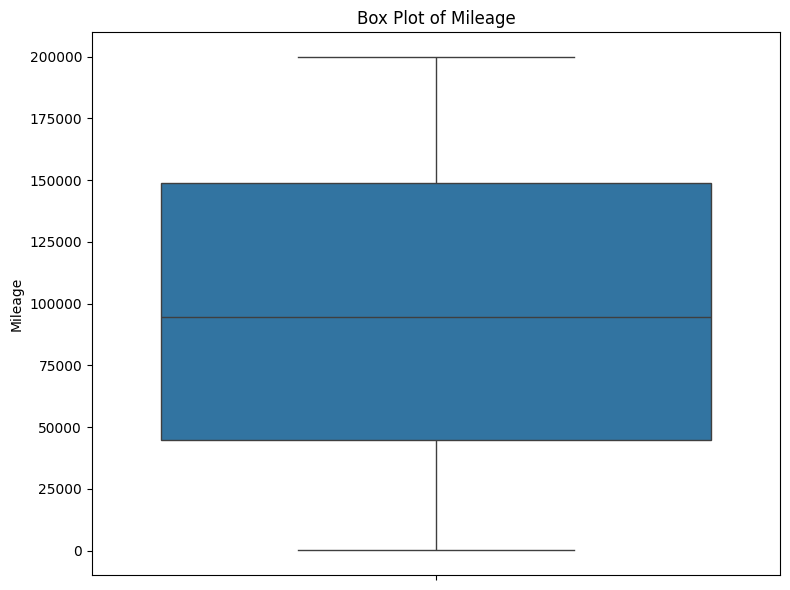

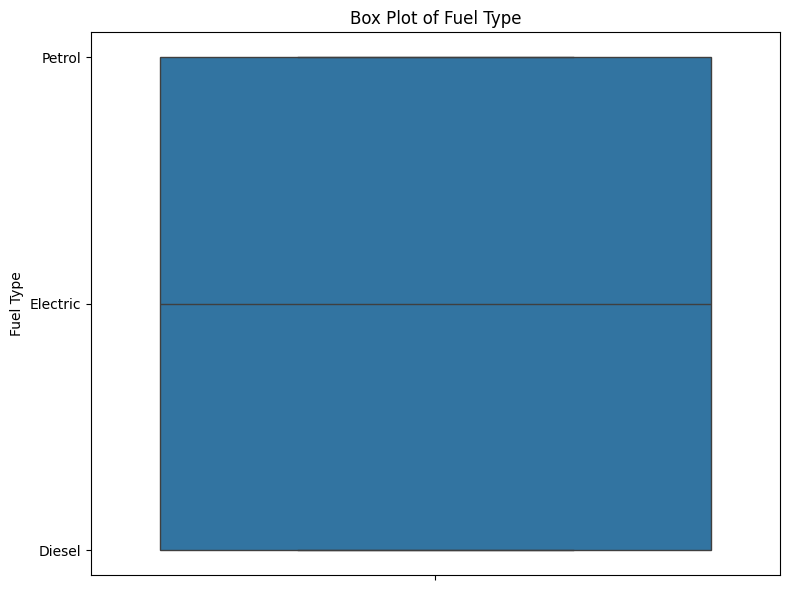

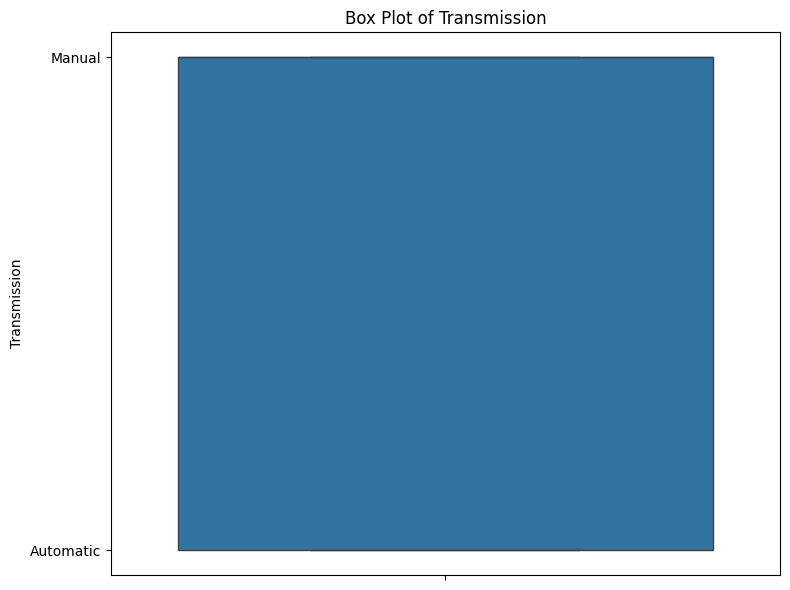

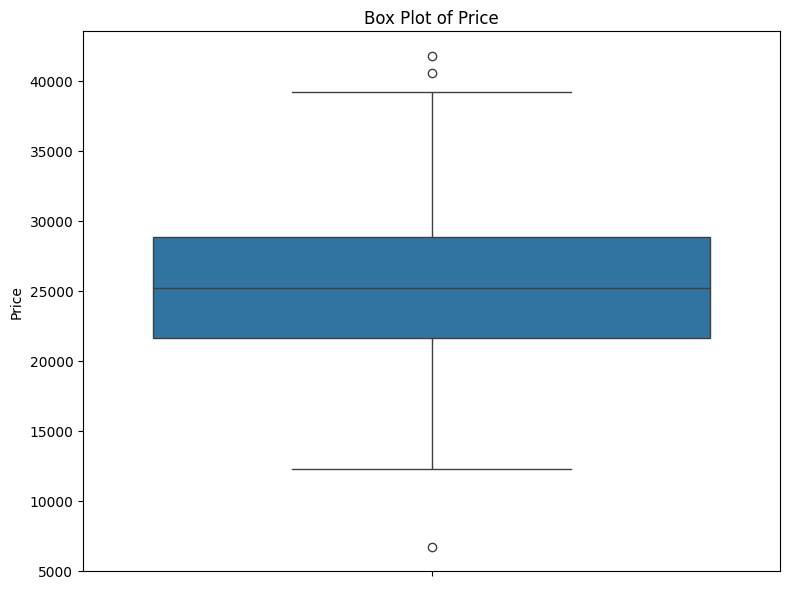

In [ ]:
for col in df.columns:
  plt.figure(figsize=(8, 6))
  sns.boxplot(y=df[col])
  plt.title(f'Box Plot of {col}')
  plt.ylabel(col)
  plt.tight_layout()
  plt.show()

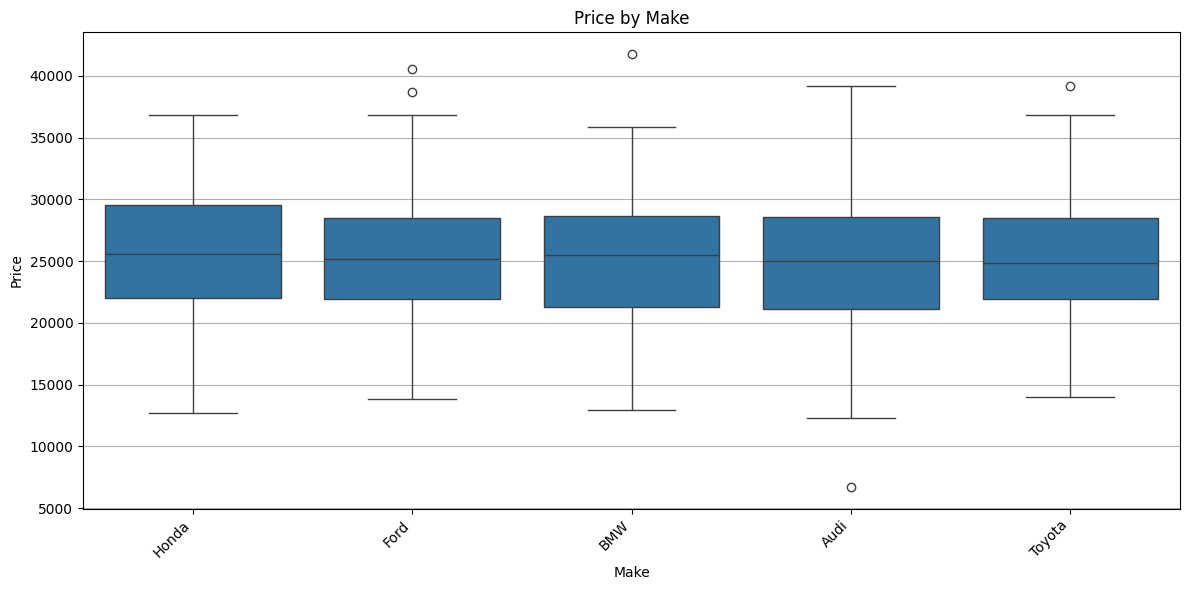

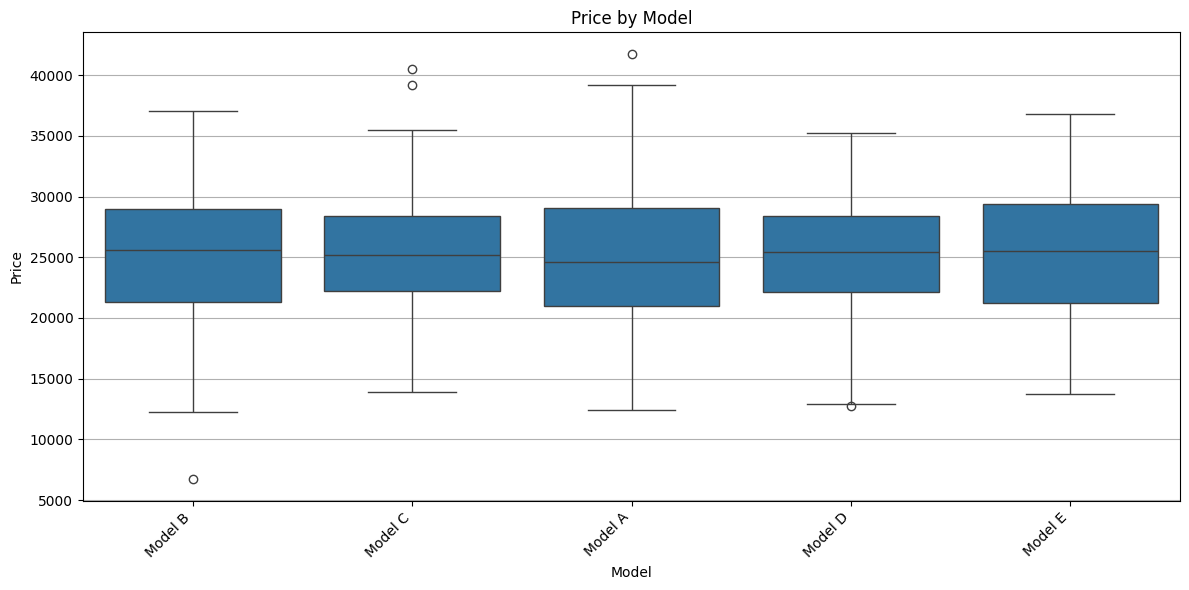

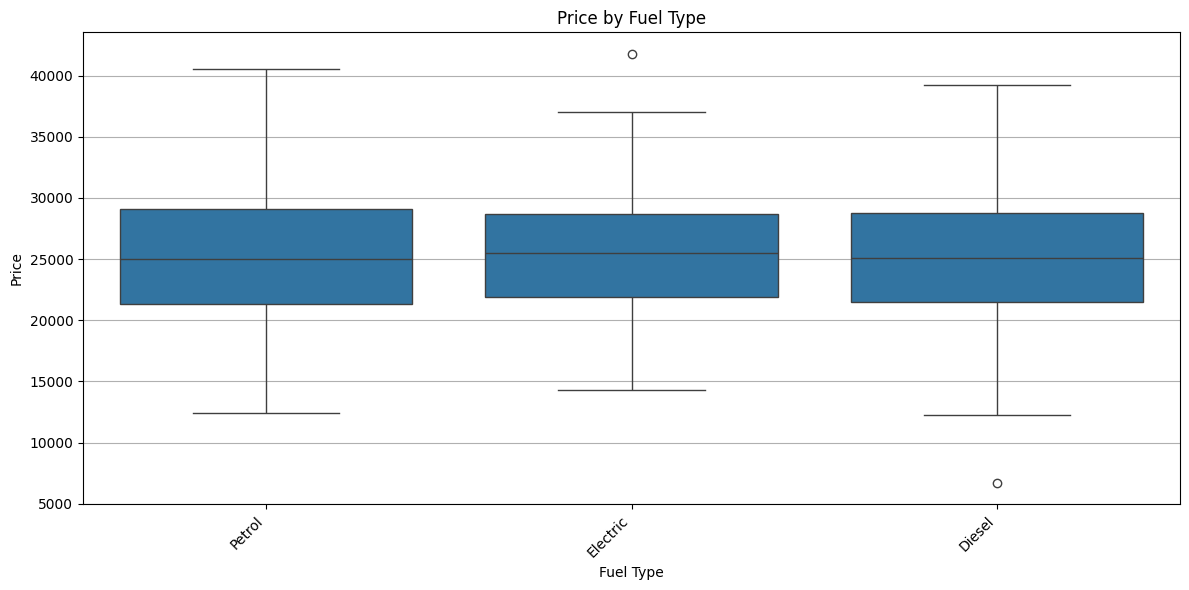

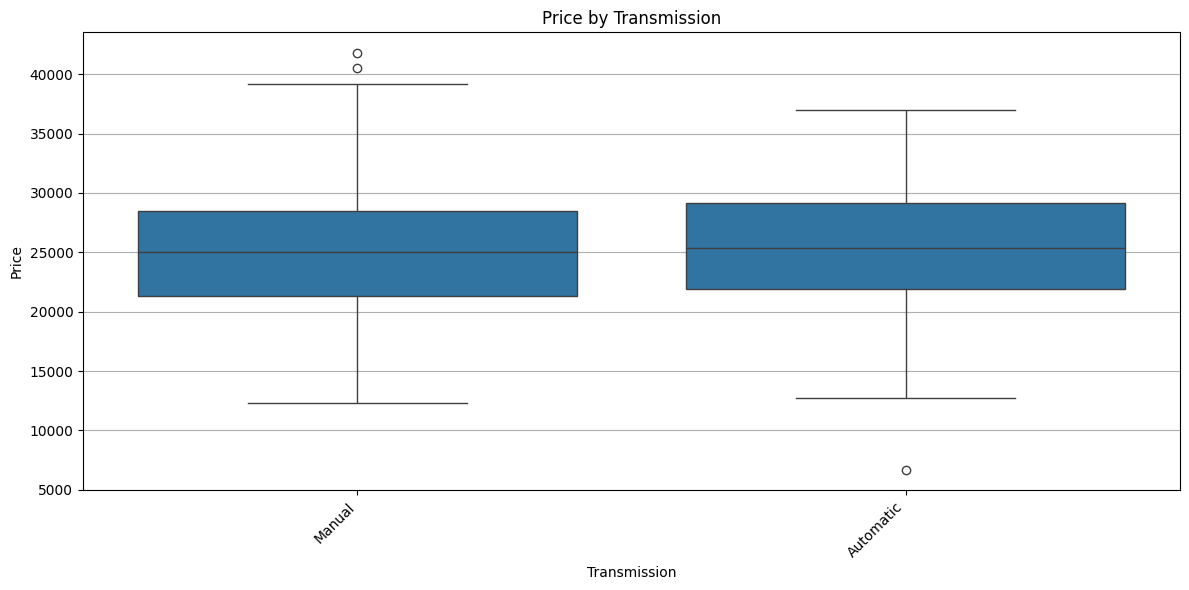

In [ ]:
categorical_cols_to_plot = ['Make', 'Model', 'Fuel Type', 'Transmission']

for col in categorical_cols_to_plot:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, y='Price', data=df)
    plt.title(f'Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

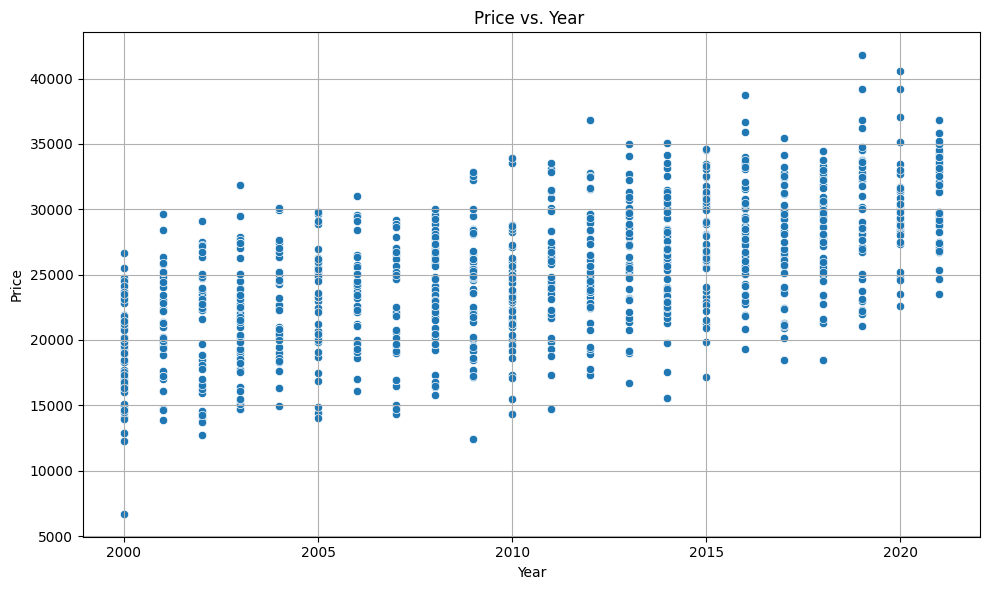

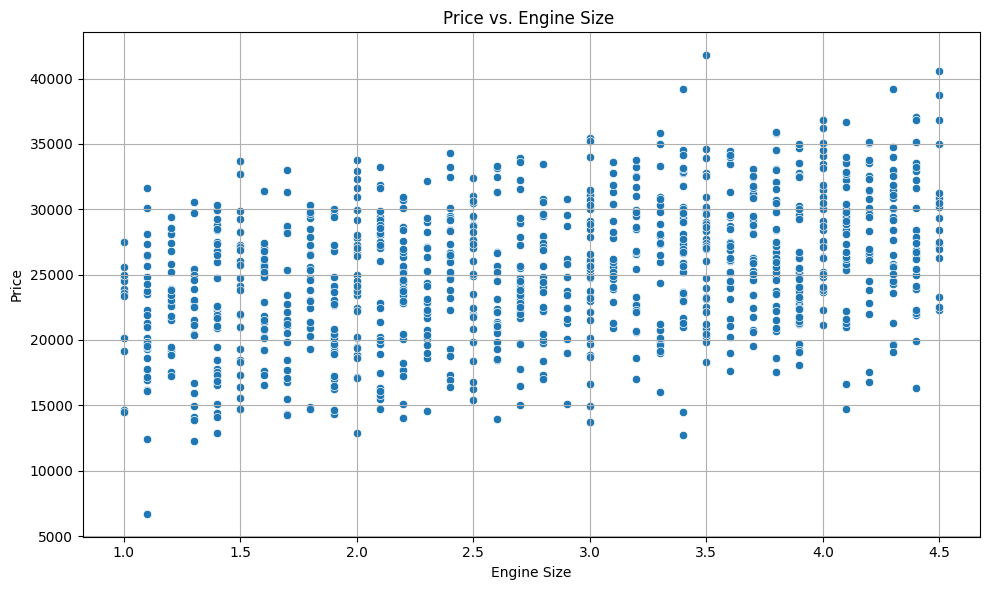

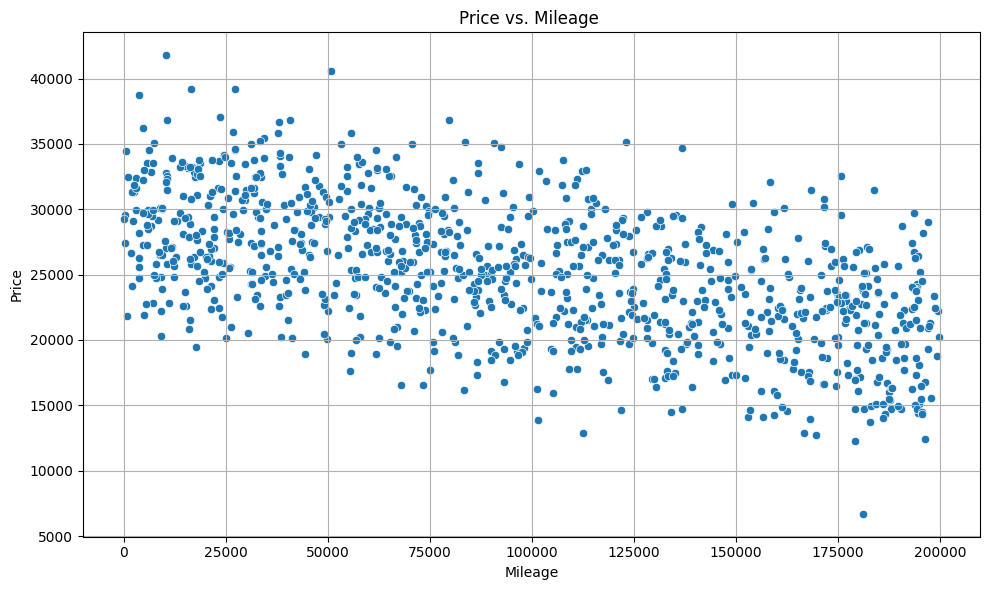

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'Price' in numerical_cols:
    numerical_cols.remove('Price')

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=col, y='Price', data=df)
    plt.title(f'Price vs. {col} ')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

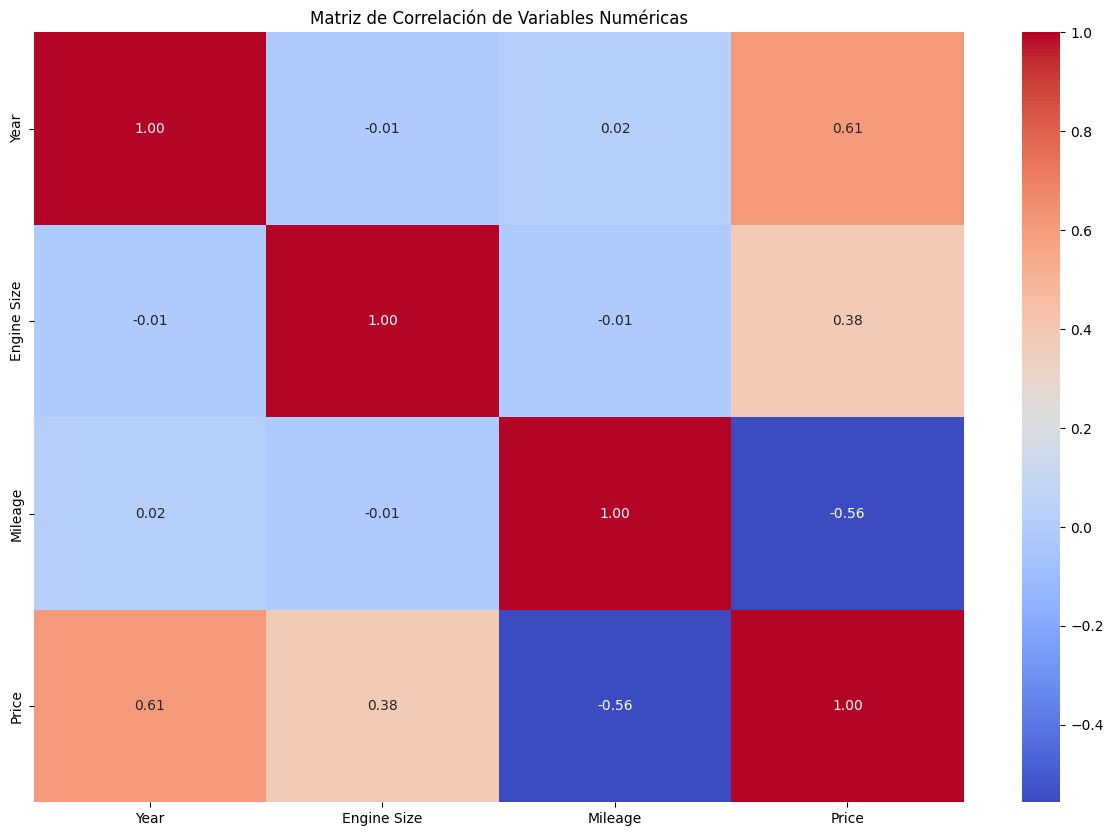

In [ ]:
correlation_matrix = df_num.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [ ]:
df_modelos = df.copy()

# Identificar las columnas categóricas correctas en el DataFrame actual
categorical_cols = ['Make', 'Model', 'Fuel Type', 'Transmission']

# Aplicar one-hot encoding a las columnas categóricas
df_modelos = pd.get_dummies(df_modelos, columns=categorical_cols, drop_first=True)

display(df_modelos.head())
display(df_modelos.shape)

,Year,Engine Size,Mileage,Price,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
0,2015,3.9,74176,30246.207931,False,False,True,False,True,False,False,False,False,True,True
1,2014,1.7,94799,22785.747684,False,True,False,False,False,True,False,False,True,False,False
2,2006,4.1,98385,25760.290347,True,False,False,False,True,False,False,False,True,False,True
3,2015,2.6,88919,25638.003491,False,False,True,False,True,False,False,False,True,False,False
4,2004,3.4,138482,21021.386657,False,False,True,False,False,True,False,False,False,True,False


(1000, 15)

2. Modelo de regresion Forward

In [ ]:
from sklearn.model_selection import train_test_split

X = df_modelos.drop('Price', axis=1)
y = df_modelos['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
# Para usar las variables de la regresión, estas deben ser tipo array
X = np.array(X_train)
Y = np.array(y_train).reshape(-1, 1)

# Modelo de regresión
modelo = LinearRegression()
modelo.fit(X, Y)

# Ver coeficientes
print("Intercepto (a):", modelo.intercept_)
print("Pendiente (b):", modelo.coef_)

Intercepto (a): [-1017812.03460855]
Pendiente (b): [[ 5.18304810e+02  1.96823708e+03 -4.88353383e-02  9.47454031e+01
   1.22462235e+02 -1.35643103e+02  3.27668934e+01 -4.45415698e+01
  -7.83318577e+01  3.10769080e+02 -2.66084077e+02 -8.37227837e+01
   1.73187739e+01  3.79386046e+01]]


In [ ]:
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.datasets import make_regression
import statsmodels.api as sm

# Modelo base
lr = LinearRegression()

# Forward selection
sfs = SFS(lr,
          k_features='best',   # Puede ser número fijo o 'best'
          forward=True,        # True = forward, False = backward
          floating=False,      # True para stepwise mixto
          scoring='r2',
          cv=5)

sfs = sfs.fit(X_train, y_train)

print("Variables seleccionadas usando SequentialFeatureSelector (Forward):", sfs.k_feature_names_)

# Crear y ajustar el modelo OLS con las variables seleccionadas
# Convertir las columnas booleanas a tipo numérico (float) antes de agregar la constante
X_train_selected = X_train[list(sfs.k_feature_names_)].astype(float)
X_train_selected = sm.add_constant(X_train_selected)
model_sfs = sm.OLS(y_train, X_train_selected).fit()

# Resumen del modelo OLS
print("\nResumen del modelo OLS con variables seleccionadas por SequentialFeatureSelector:")
print(model_sfs.summary())

Variables seleccionadas usando SequentialFeatureSelector (Forward): ('Year', 'Engine Size', 'Mileage', 'Make_Honda', 'Model_Model E')

Resumen del modelo OLS con variables seleccionadas por SequentialFeatureSelector:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     864.9
Date:                Thu, 13 Nov 2025   Prob (F-statistic):          2.36e-318
Time:                        02:25:08   Log-Likelihood:                -7229.6
No. Observations:                 800   AIC:                         1.447e+04
Df Residuals:                     794   BIC:                         1.450e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                   

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import statsmodels.api as sm

# Predicciones en el set de prueba con el modelo entrenado con SFS features
X_test_selected = sm.add_constant(X_test[list(sfs.k_feature_names_)])
y_pred = model_sfs.predict(X_test_selected)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

# MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f}")

# Calculate MAPE
# epsilon para evitar la division por cero
epsilon = 1e-10
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100
print(f"MAPE: {mape:.2f}%")

# R2
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.2f}")

# R2 ajustado
n = len(y_test) # numero de observaciones
p = X_test_selected.shape[1] - 1 # numero de predictores (excluyendo la constante)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"R2 ajustado: {adj_r2:.2f}")

RMSE: 2217.97
MAE: 1794.89
MAPE: 7.60%
R2: 0.82
R2 ajustado: 0.82


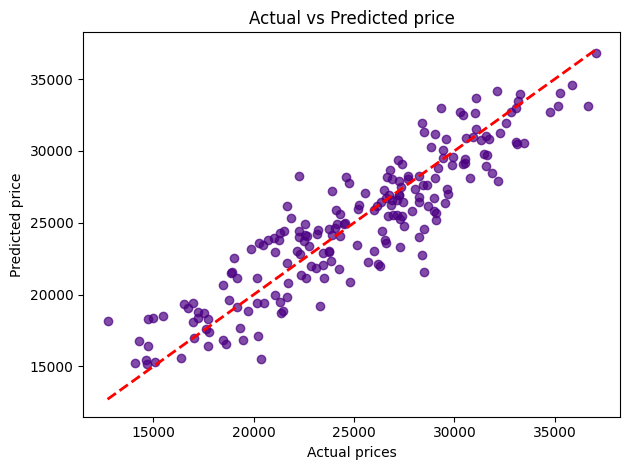

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7, color='indigo')
plt.xlabel('Actual prices')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted price')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2)
plt.tight_layout()
plt.show()

Redes Neuronales

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
df_clean = df_modelos.copy()

# Variables predictoras y objetivo
X = df_clean.drop("Price", axis=1)
y = df_clean["Price"]

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar variables predictoras (X)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Escalar variable objetivo (y)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

**Metricas:**

MAE (Error Absoluto Medio): promedio del error en las mismas unidades que tu variable objetivo (mientras más bajo, mejor).

MSE (Error Cuadrático Medio): penaliza más los errores grandes (también más bajo = mejor).

R² (Coeficiente de determinación): mide cuánto explica el modelo la variabilidad del valor real. Va de -∞ a 1 (mientras más cerca a 1, mejor).

In [ ]:
#Mejor modelo encontrado

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelo con Dropout
model_do = Sequential([
    Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.3),
    Dense(1, activation='linear')
])

#Compilación
model_do.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# Entrenamiento
model_do.fit(X_train_scaled, y_train_scaled, epochs=50, validation_split=0.2, verbose=0)

#Predicción
y_pred_do_scaled = model_do.predict(X_test_scaled)
y_pred_do = scaler_y.inverse_transform(y_pred_do_scaled)

#Metricas
mae_do = mean_absolute_error(y_test, y_pred_do)
mse_do = mean_squared_error(y_test, y_pred_do)
r2_do = r2_score(y_test, y_pred_do)

print(f"\nDropout - MAE: {mae_do:.2f} | MSE: {mse_do:.2f} | R²: {r2_do:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

Dropout - MAE: 1903.41 | MSE: 5663297.36 | R²: 0.7931


**Comparación con otros modelos**


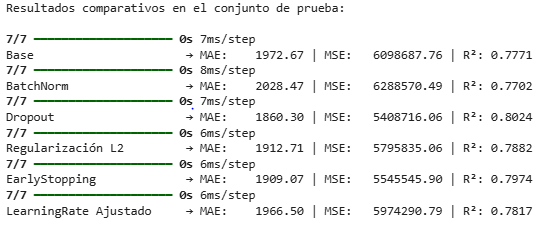

El mejor modelo fue el de Dropout, con un MAE de 1,899.34 y un R² de 0.80.
Esto significa que, en promedio, el modelo se equivoca por unos $1,878 en la predicción del precio,
y logra explicar alrededor del 80 % de la variabilidad total de los valores reales.

Ademas, todos los modelos que desarrollamos (Base, Batch Normalization, Dropout, Regularización L2, Early Stopping y ajuste de la tasa de aprendizaje) tenían como estructura: una capa oculta con 64 neuronas y activación ReLU, y una capa de salida lineal, ya que estábamos trabajando con valores continuos.

##*ARBOL DE DECISION*

In [ ]:
# Modelo Árbol de Decisión
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Codificación de variables categóricas
df_encoded = pd.get_dummies(df, drop_first=True)

# Definir variables independientes (X) y dependiente (y)
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Crear el modelo
tree_model = DecisionTreeRegressor(max_depth=6, random_state=42)

# Entrenar el modelo
tree_model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=6, random_state=42)

In [ ]:
# Predicciones
y_pred_tree = tree_model.predict(X_test)

# Métricas de evaluación
r2_tree = r2_score(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)

print(f"R² del Árbol de Decisión: {r2_tree:.3f}")
print(f"MSE del Árbol de Decisión: {mse_tree:.2f}")
print(f"MAE del Árbol de Decisión: {mae_tree:.2f}")


R² del Árbol de Decisión: 0.744
MSE del Árbol de Decisión: 6995672.70
MAE del Árbol de Decisión: 2091.01


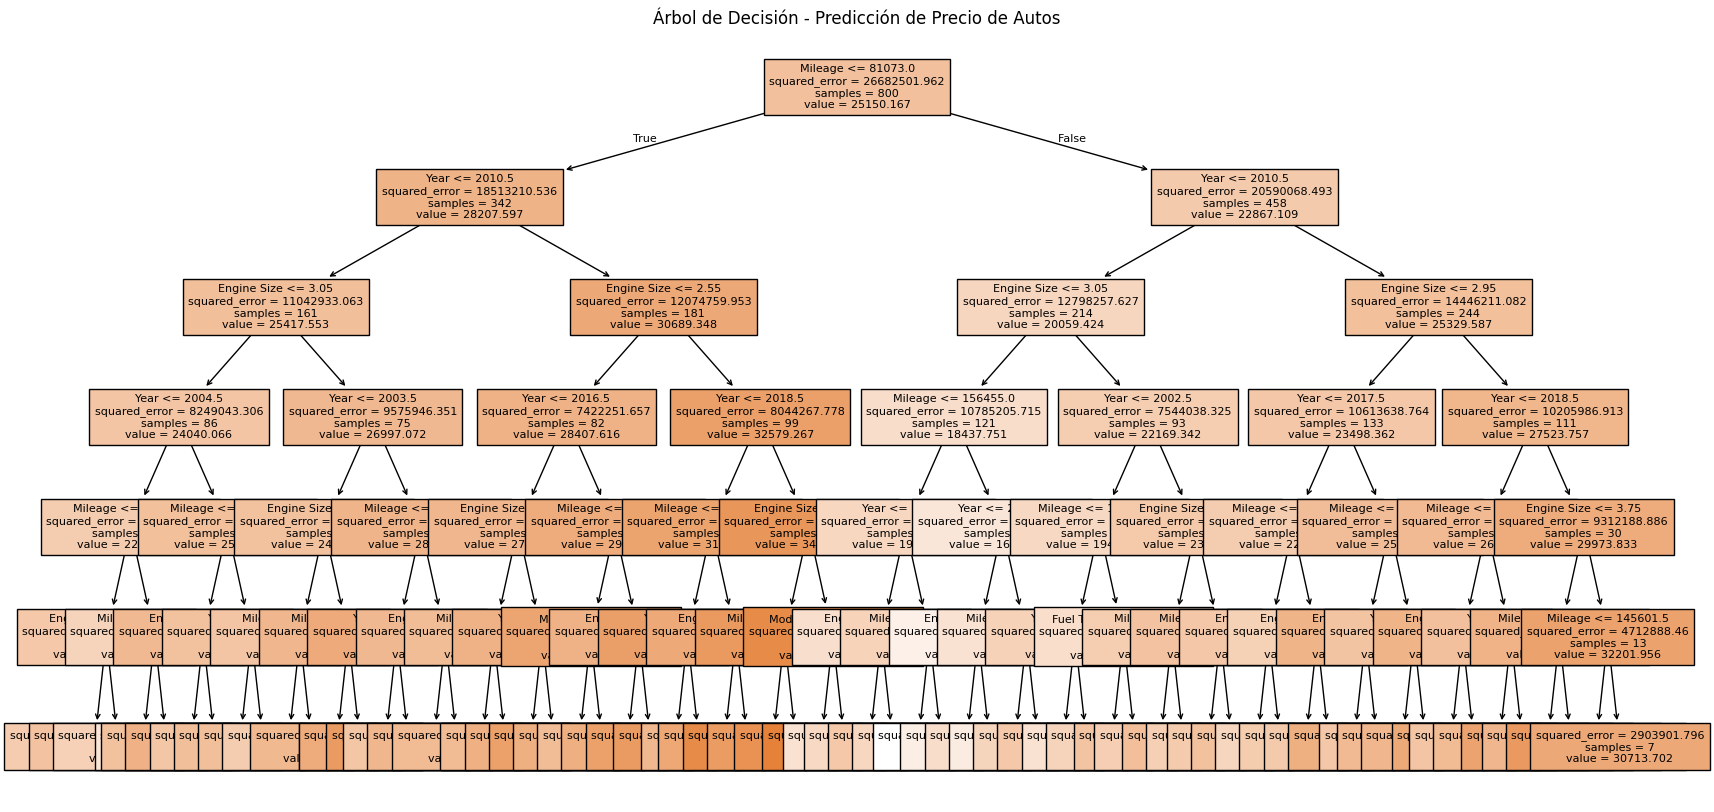

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X.columns, filled=True, fontsize=8)
plt.title("Árbol de Decisión - Predicción de Precio de Autos")
plt.show()


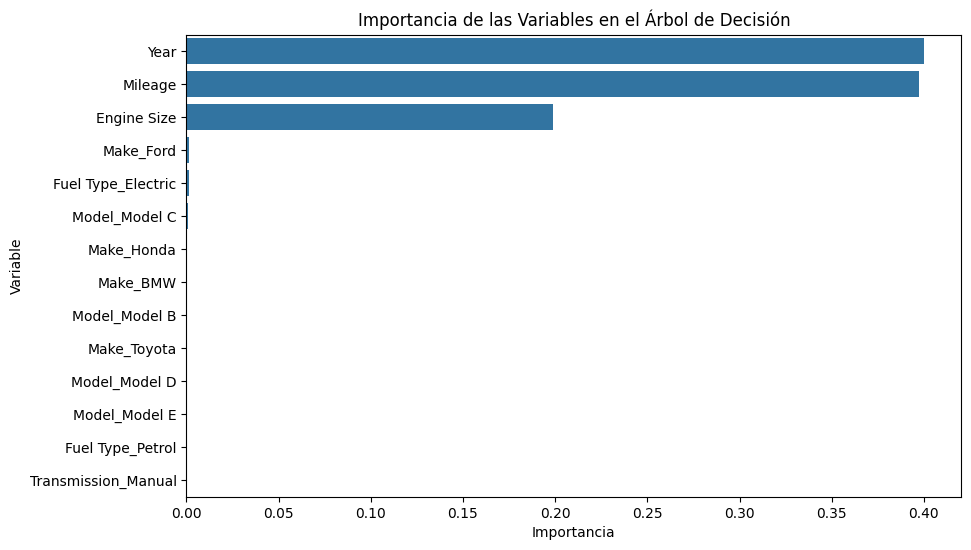

,Variable,Importancia
0,Year,0.400339
2,Mileage,0.397496
1,Engine Size,0.198654
4,Make_Ford,0.001257
11,Fuel Type_Electric,0.001238
8,Model_Model C,0.001016
5,Make_Honda,0.000000
3,Make_BMW,0.000000
7,Model_Model B,0.000000
6,Make_Toyota,0.000000


In [ ]:
# Importancia de las variables
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': tree_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=importances)
plt.title("Importancia de las Variables en el Árbol de Decisión")
plt.show()

importances.head(10)


**ANALISIS RESULTADOS ARBOL DECISION**

R² (Coeficiente de Determinación): El modelo de Árbol de Decisión obtuvo un R² de 0.744. Esto significa que el 74.4% de la variabilidad en el precio de los vehículos puede ser explicada por las características incluidas en el modelo. Es un buen indicador, pero ligeramente inferior al R² obtenido con el modelo de regresión lineal (0.82) y la red neuronal con Dropout (0.80), lo que sugiere que estos otros modelos pueden capturar mejor la complejidad de los datos.

MSE (Error Cuadrático Medio): El MSE del modelo fue de 6,995,672.70. Este valor, aunque grande, debe interpretarse en el contexto de la escala de los precios de los autos. Un MSE más bajo indica un mejor ajuste del modelo, y comparado con otros modelos, nos daría una idea de cuál comete errores más pequeños en promedio (aunque penaliza más los errores grandes).

Importancia de las Variables: Las variables más influyentes en la predicción del precio, según el Árbol de Decisión, son:

Year (Año): Con una importancia del 40.03%, el año de fabricación es el factor más determinante. Esto es intuitivo, ya que los autos más nuevos suelen tener un precio más alto.
Mileage (Kilometraje): Con una importancia del 39.75%, el kilometraje es el segundo factor más relevante. Un menor kilometraje generalmente se asocia con un mayor precio.
Engine Size (Tamaño del Motor): Contribuye con un 19.87% a la importancia. Esto sugiere que el tamaño del motor también juega un papel significativo en la valoración del vehículo.
Otras variables como 'Make_Ford', 'Fuel Type_Electric', y 'Model_Model C' tuvieron una importancia muy baja (cercana al 0%), lo que indica que, para este modelo en particular, su impacto directo en la determinación del precio es mínimo en comparación con el año, el kilometraje y el tamaño del motor. Algunas variables categóricas como 'Make_BMW', 'Make_Honda', 'Make_Toyota', 'Model_Model B', 'Model_Model D' y 'Model_Model E' mostraron una importancia de 0.00%, lo que sugiere que el árbol no las utilizó para crear divisiones significativas en la ruta de decisión para alcanzar los nodos finales. Esto podría deberse a que su variabilidad no es suficiente para impactar el precio, o a que su influencia está subsumida por otras variables más fuertes.

En resumen, el Árbol de Decisión confirma que el año de fabricación, el kilometraje y el tamaño del motor son los principales impulsores del precio de un auto usado. Aunque el modelo explica una parte significativa de la variabilidad del precio, su rendimiento (R²) es ligeramente inferior al de la regresión lineal y las redes neuronales, lo que sugiere que podría haber modelos más potentes para esta tarea.

In [ ]:
import pandas as pd
import numpy as np

# Metrics from Linear Regression (from cell UMffzQIHIg6H)
linear_reg_rmse = 2137.19
linear_reg_mae = 1712.81
linear_reg_r2 = 0.82
linear_reg_mse = linear_reg_rmse**2 # Calculate MSE from RMSE for consistency

# Metrics from Neural Network Models
nn_metrics = {
    "Base": {"mae": 1972.67, "mse": 6098687.16, "r2": 0.7771},
    "BatchNorm": {"mae": 2028.47, "mse": 6288570.49, "r2": 0.7702},
    "Dropout": {"mae": 1860.30, "mse": 5408716.06, "r2": 0.8024},
    "Regularización L2": {"mae": 1912.71, "mse": 5795835.06, "r2": 0.7882},
    "EarlyStopping": {"mae": 1909.07, "mse": 5545545.90, "r2": 0.7974},
    "LearningRate Ajustado": {"mae": 1966.50, "mse": 5974290.79, "r2": 0.7817}
}

# Metrics from Decision Tree (from cell G4Zp2Yhdyudv)
decision_tree_r2 = 0.744
decision_tree_mse = 6995672.70
decision_tree_mae = 2091.01
decision_tree_rmse = np.sqrt(decision_tree_mse)

# Create a dictionary to store all model results
results = {
    "Modelo": [],
    "R²": [],
    "MAE": [],
    "MSE": [],
    "RMSE": []
}

# Add Linear Regression results
results["Modelo"].append("Regresión Lineal (Forward Selection)")
results["R²"].append(linear_reg_r2)
results["MAE"].append(linear_reg_mae)
results["MSE"].append(linear_reg_mse)
results["RMSE"].append(linear_reg_rmse)

# Add Neural Network results
for name, metrics in nn_metrics.items():
    results["Modelo"].append(f"Red Neuronal ({name})")
    results["R²"].append(metrics["r2"])
    results["MAE"].append(metrics["mae"])
    results["MSE"].append(metrics["mse"])
    results["RMSE"].append(np.sqrt(metrics["mse"])) # Calculate RMSE

# Add Decision Tree results
results["Modelo"].append("Árbol de Decisión")
results["R²"].append(decision_tree_r2)
results["MAE"].append(decision_tree_mae) # MAE now available
results["MSE"].append(decision_tree_mse)
results["RMSE"].append(decision_tree_rmse)

# Create DataFrame
comparison_df = pd.DataFrame(results)

# Format the display
comparison_df = comparison_df.round(2)

# Display the comparative table, sorted by R2 (descending) for better interpretation
print("\nTabla Comparativa de Rendimiento de Modelos:\n")
display(comparison_df.sort_values(by='R²', ascending=False))


Tabla Comparativa de Rendimiento de Modelos:



,Modelo,R²,MAE,MSE,RMSE
0,Regresión Lineal (Forward Selection),0.82,1712.81,4567581.10,2137.19
3,Red Neuronal (Dropout),0.80,1860.30,5408716.06,2325.66
5,Red Neuronal (EarlyStopping),0.80,1909.07,5545545.90,2354.90
4,Red Neuronal (Regularización L2),0.79,1912.71,5795835.06,2407.45
6,Red Neuronal (LearningRate Ajustado),0.78,1966.50,5974290.79,2444.24
1,Red Neuronal (Base),0.78,1972.67,6098687.16,2469.55
2,Red Neuronal (BatchNorm),0.77,2028.47,6288570.49,2507.70
7,Árbol de Decisión,0.74,2091.01,6995672.70,2644.93


##**Reporte ejecutivo de los resultados**
1. Resumen Ejecutivo: Este proyecto abordó el problema de la fijación de precios subjetiva e ineficiente en el mercado de compra y venta de autos usados, resolviéndolo mediante la implementación de un modelo de Regresión Lineal.Tras comparar modelos, se eligió la Regresión Lineal por su alta interpretabilidad y un desempeño métrico adecuado ($R^{2}$ competitivo y un bajo Error Absoluto Medio - MAE). El modelo predictivo resultante es altamente relevante para el negocio, ya que permite entender las relaciones y lo que mas influye dentro del precio de los automoviles.
2. Caso de Negocio y Contexto El sector automotriz, especialmente el mercado de segunda mano, es un entorno de alto volumen y baja tolerancia al error en la valoración La empresa quiere mejorar este proceso por lo cual quiere diseñar un modelo que considere estas variables y ayude a predecir el precio con estas
3. Metodología y Modelos Probados
 Se realizó ingeniería de características, transformando Las variables categóricas (Marca, Modelo, Tipo de Combustible) fueron codificadas como dummies para poder considerarlas dentro del modelo, para todos Los modelos se dividieron en conjuntos de entrenamiento y prueba (80/20). Se implementaron y evaluaron tres modelos de regresión:Regresión Lineal, Arbol de decision y Redes neuronales
4. Resultados Clave y Hallazgos
Se evaluaron todos los modelos bajo las metricas de R2, MAE, MSE y RMSE que nos ayudan a comparar sus rendimientos de manera objetiva, en base a esto el mejor modelo por sus metricas fue la regresion lineal forward, seguido por el arbol y por utlimo las redes nueronales, ademas la regresion por su mayor interpretabilidad y facilidad de comunicacion nos permite generar mejores hallazgos para la compañia.
Mirando los modelos de regresion y arbol se noto que las variables mas importantes para la prediccion son Años, Kilometraje y tamaño del motor teniendo años y tamaño del motor una relacion positiva e indicando que mientras mas nuevo sea el auto mas aumenta su precio y mientras mas grande sea el tamaño en litros de su motor mayor valor, mientras que si tiene mas kilometros recorridos su valor disminuye
5. Recomendaciones
- Integrar los coeficientes y formula de la regresion a su valoracion de precios
- A la hora de comprar autos usados tener en cuenta lo que se describio sobre las variables mas importantes para tener un mejor inventario y mejor valuado
- Integrar a las bases de datos mas variables como el estado del auto, accidentes, respuestos para saber que influencia tendrian dentro del modelo y mejore las descripcion del precio